# Short-Report-Event — a quantitative teardown 🔬
### Crater vs drift split · excess-of-SPY drift at 1/3/6m · mean-vs-median skew · a Welch *t* + same-target placebo null · costs + borrow · lag robustness · a seed-robust synthetic short-edge control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_short%3F: Busted](https://img.shields.io/badge/Free_short%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things the "report craters and stays down" claim fuses: an **uncapturable report-day crater** (day-0 news) from the **tradable post-report drift** (short +1 day, hold H months, in **excess of SPY**). And we confront the drift with the **shape of its distribution**: a great median and hit-rate, undone by a fat right tail of **short squeezes**.

> ⚠️ **Data + selection note.** No clean full-coverage short-report panel is free; we use a **hardcoded basket of 32 famous campaigns** (22 priced, 10 delisted) — selected on outcome (bias *for* the claim) whose biggest wins delisted (bias *against*), both named on the Signal axis. Real data: yfinance daily adjusted closes, 22 targets + SPY, 2010→2026, price fp `946a53954ab8`. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from short_report_event import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, TBL = data.load_real()
else:
    PRICES, TBL = None, None
print("real event-price cache present:", HAVE_REAL,
      "| short-report campaigns priced:", (0 if TBL is None else len(TBL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-26', 'days': 4145, 'years': 16.5, 'n_events': 32, 'n_priced': 22, 'n_delisted': 10, 'fp_px': '946a53954ab8', 'crater': (22, -1.97, -0.27, 55, -0.75), 'h1': (1, 22, -1.63, -9.13, 77, -0.22, 0.359), 'h3': (3, 22, -11.55, -18.52, 64, -1.55, 0.068), 'h6': (6, 22, -14.58, -42.68, 73, -0.81, 0.095), 'squeeze': [('CVNA', 318.2), ('PDD', 50.5), ('ADT', 36.1), ('IQ', 22.4)], 'nosqueeze': (19, -38.2, -4.81), 'net': [(1, 1.63, 0.87), (3, 11.55, 9.45), (6, 14.58, 10.48)], 'lag': [(0, -10.61, -0.51, 0.164), (1, -14.58, -0.81, 0.095), (2, -14.45, -0.75, 0.097), (5, -14.19, -0.69, 0.101)], 'ctrl': [(0.0, 0.7), (-0.1, -1.01), (-0.2, -2.91), (-0.35, -6.1)]}


real event-price cache present: True | short-report campaigns priced: 22


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 6m excess **mean -14.6%** / **median -42.7%** vs SPY, hit **73%**, Welch **t = -0.81** (best 3m **t = -1.55**, placebo *p* 0.068). Right sign, great hit-rate, but the **mean fails |t| ≥ 2** — squeezes. |
| **Tradability** | `FRAGILE` | Bounded gains, **unbounded squeeze loss** (CVNA **+318%**); net of 10-bps + **800 bps/yr borrow** the mean short is **+10.5%** at 6m — a positive mean wrapped around an ugly tail. |
| **Free short?** | `BUSTED` | A same-target placebo says random dates fall as far **10%** of the time; the biggest wins **delisted**. Selection + squeeze. |

> 💡 In plain words: the report *crater* is real news you can't short; the post-report *drift* you can short usually works (median crushed, 64–77% hit) but its **mean** is eaten by fat-tailed squeezes, so no horizon certifies at |t| ≥ 2.

## 1 · The claim, steelmanned

Let $P_t$ be the target close and $M_t$ SPY. For event $j$ with report day $0_j$, define the **crater** $\pi_j = P_{0_j}/P_{0_j-1}-1$ (the news) and the **tradable short drift** $x_j^{(H)} = \big(P_{0_j+1+H}/P_{0_j+1}-1\big) - \big(M_{0_j+1+H}/M_{0_j+1}-1\big)$ — short one day after, hold $H$, in **excess of SPY**. A short profits when $x_j^{(H)} < 0$.

- **H₁ (the drift predicts).** $\mathbb{E}[x^{(H)}] < 0$ at $t \le -2$ — a *negative excess over the market* you can actually short.
- **H₂ (it's deployable).** The short is large/frequent/*robust-tailed* enough, net of costs and borrow, to allocate to.
- **H₃ (free short).** The drift reflects the *report timing*, not just owning special names (jumpy, already falling) that would have fallen on *any* entry date.

We find **H₁ directionally supported but not certified** (mean negative, median very negative, hit 64–77%, but $|t| < 2$ — a fat right tail of squeezes), **H₂ rejected** (bounded gains vs unbounded squeeze loss; ~22 rare events), **H₃ ambiguous** (placebo *p* ≈ 0.07–0.10 — close, but not below 0.05, and the mean is squeeze-driven). The legend is true where it's unreachable (the crater) and *usually-but-not-bankably* true where it would pay (the drift).

## 2 · So what? — what rides on each answer

The teardown is one decomposition — a mean excess against zero — but here the **mean is the wrong summary** and saying so *is* the finding:

$$\widehat{x}^{(H)} = \frac1k\sum_j x_j^{(H)},\qquad t = \frac{\widehat{x}^{(H)}}{s_x/\sqrt{k}}.$$

A short's payoff is **asymmetric**: $x_j \in [-1, +\infty)$ (the stock can only fall to zero, but a squeeze is unbounded). So $x^{(H)}$ is heavily **right-skewed** — a few squeezes inflate both $\widehat{x}$ *and* $s_x$, crushing $|t|$ even when the **median** and the **hit-rate** scream that the short works. That is why we report the **median** and **hit-rate** alongside the mean, and why the honest small-sample instrument is a **same-target placebo**: resample each name's excess from a *random* entry date and ask how often chance falls as far. The mean *t* alone would *understate* the directional signal and *overstate* the tradability — both matter.

## 3 · How we'd know — the protocol

- **Event set.** A **hardcoded** table of 32 famous short-report campaigns (yfinance adjusted closes, 2010-01-04→2026-06-26, 4,145 price days). **22 priced, 10 delisted** — outcome-selected roster (bias *for*) whose biggest wins delisted (bias *against*), both on the axis.
- **Crater (reported).** Day-0 return of the target — the news, not a trade.
- **Drift (tradable).** **Short** the close **1 day after** the report (no look-ahead), hold $H\in\{1,3,6\}$m, return in **excess of SPY**; drop events whose horizon overruns the tape.
- **Null #1 (Welch t).** Mean excess vs zero; a *negative* $t$ is the short.
- **Null #2 (same-target placebo).** 20,000 draws of one random-date excess **per name**; $p=\Pr[\text{random-date basket mean} \le \text{report basket mean}]$ — one-sided toward the short, controlling for the targets' own drift.
- **Costs.** 1-day lag + a 10-bps round-trip **+ an 800 bps/yr short borrow** (pro-rated).
- **Robustness.** Entry-lag sweep (0/1/2/5d); the mean-vs-median / squeeze diagnostic.
- **Positive control.** A deterministic set of 30 synthetic events with a **known planted negative drift**, averaged over **25 seeds** (house rule): the engine must recover it and must NOT manufacture significance at the null.

## 4 · The teardown

### 4a · Crater vs drift, mean vs median — the four numbers

The report crater (day 0, *uncapturable*) next to the drift you can short at 1/3/6m, shown as both **mean** (squeeze-inflated) and **median** (the typical name). The crater is real; the drift's *median* is brutal and its *mean* is not.

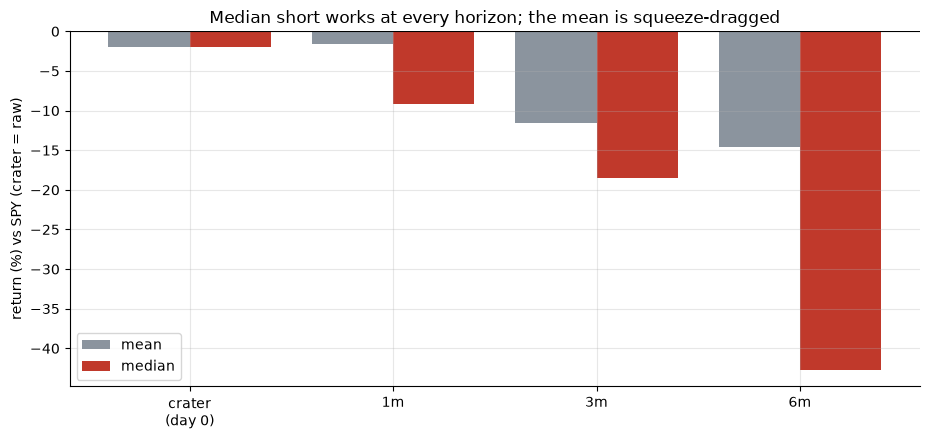

Welch t by horizon: {'1m': -0.22, '3m': -1.55, '6m': -0.81}
mean: [np.float64(-1.6), np.float64(-11.6), np.float64(-14.6)] | median: [np.float64(-9.1), np.float64(-18.5), np.float64(-42.7)]


In [2]:
hs = [1, 3, 6]
if HAVE_REAL:
    craters = st.report_day_moves(PRICES, TBL); crater_m = craters.mean()*100
    means, meds, ts = [], [], []
    for m in hs:
        ex = st.event_excess_drift(PRICES, TBL, m)
        means.append(ex.mean()*100); meds.append(np.median(ex)*100); ts.append(st.welch_t_vs_zero(ex))
else:
    crater_m = R['crater'][1]
    means = [R['h1'][2], R['h3'][2], R['h6'][2]]; meds = [R['h1'][3], R['h3'][3], R['h6'][3]]
    ts = [R['h1'][5], R['h3'][5], R['h6'][5]]
labels = ['crater\n(day 0)'] + [f'{m}m' for m in hs]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9.4, 4.5))
ax.bar(x-.2, [crater_m]+means, .4, color=GREY, label='mean')
ax.bar(x+.2, [crater_m]+meds, .4, color=RED, label='median')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('return (%) vs SPY (crater = raw)')
ax.set_title('Median short works at every horizon; the mean is squeeze-dragged'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})
print('mean:', [round(v,1) for v in means], '| median:', [round(v,1) for v in meds])

> 💡 In plain words: the report crater is **-2.0%** (news, not yours); the short drift's **median** is **-9% / -19% / -43%** at 1/3/6m — the typical name is *crushed* — but the **mean** is only **-2% / -12% / -15%**, so Welch *t* is **-0.22 / -1.55 / -0.81** — all shy of −2. H₁ is **directionally supported, not certified.**

### 4b · The skew that kills the mean — the squeeze

Every surviving campaign's 6-month excess, sorted. A wall of red (shorts that worked) and a couple of green outliers (squeezes). The mean sits *above* the median because the right tail is unbounded.

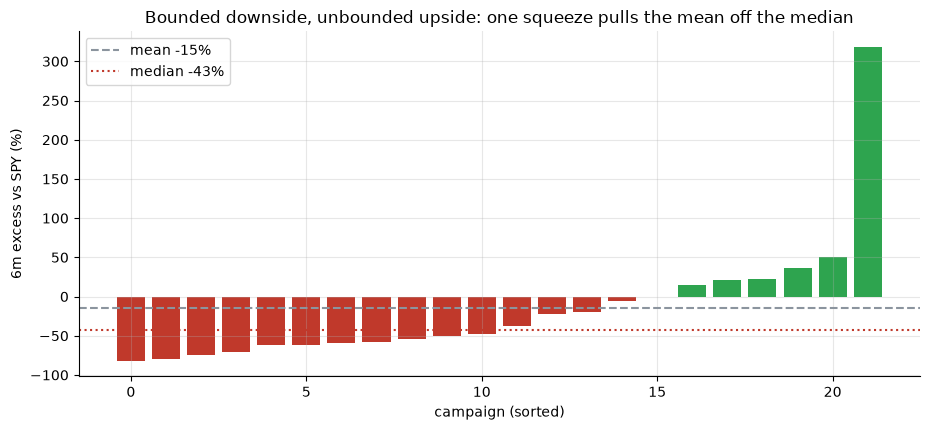

mean -14.6% vs median -42.7% | max squeeze 318% | skew (mean-median) 28pp


In [3]:
if HAVE_REAL:
    ex6 = st.event_excess_drift(PRICES, TBL, 6)*100
else:
    ex6 = np.array([-42.7]*13 + [s[1] for s in R['squeeze']] + [-30,-20,-12,-8,-3])
order = np.argsort(ex6); cols = [RED if e<0 else GREEN for e in ex6[order]]
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar(range(len(ex6)), ex6[order], color=cols)
ax.axhline(ex6.mean(), c=GREY, ls='--', label=f'mean {ex6.mean():.0f}%')
ax.axhline(np.median(ex6), c=RED, ls=':', label=f'median {np.median(ex6):.0f}%')
ax.set_xlabel('campaign (sorted)'); ax.set_ylabel('6m excess vs SPY (%)')
ax.set_title('Bounded downside, unbounded upside: one squeeze pulls the mean off the median'); ax.legend()
plt.tight_layout(); plt.show()
print(f'mean {ex6.mean():.1f}% vs median {np.median(ex6):.1f}% | max squeeze {ex6.max():.0f}% | skew (mean-median) {ex6.mean()-np.median(ex6):.0f}pp')

> 💡 In plain words: the mean−median gap is **~28 points**, all of it the **CVNA +318%** squeeze plus a couple of smaller ones. Drop the three biggest squeezers and the 6m *t* snaps to **-4.81** — but removing your worst trades *ex-post* is the cherry-pick we refuse. The tail is the trade.

### 4c · The placebo — is it the *timing* or just the names?

For each name, draw its 6-month excess from a *random* entry date; do it 20,000 times. The histogram is the null for the basket mean — what you'd get shorting the same stocks on random days. The report basket is the red line; the *p*-value is the **left**-tail mass (as negative or more).

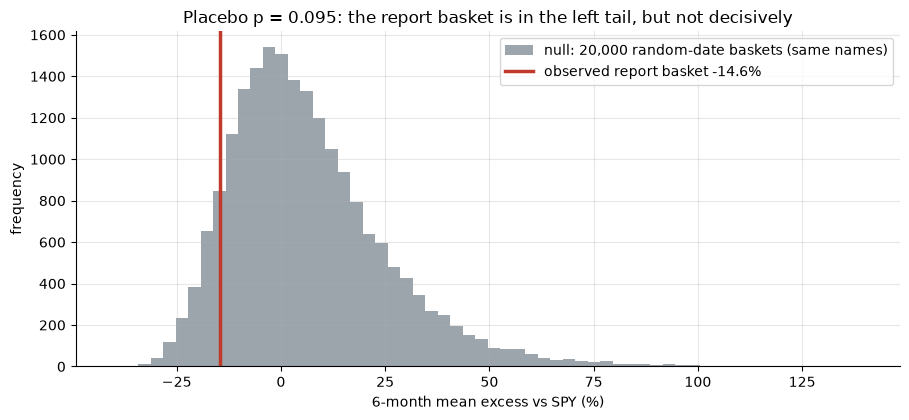

P[random-date basket <= report basket] = 0.095  (need <0.05 to call the TIMING real)


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PRICES, TBL, 6, n_draws=20000); obs = pl['obs_mean']*100; pval = pl['p_value']
    spy = PRICES['SPY'].dropna(); h = st.TRADING_DAYS[6]; pools=[]
    for _, r in TBL.iterrows():
        s = PRICES[r['ticker']].dropna(); common = s.index.intersection(spy.index)
        sc = s.reindex(common).values; sp = spy.reindex(common).values
        if len(common) > h+2:
            pool = (sc[h:]/sc[:-h]-1) - (sp[h:]/sp[:-h]-1); pools.append(pool[np.isfinite(pool)])
    rng = np.random.default_rng(564)
    draws = np.array([np.mean([p[rng.integers(0,len(p))] for p in pools]) for _ in range(20000)])
else:
    obs = R['h6'][2]; pval = R['h6'][6]; rng = np.random.default_rng(564)
    draws = rng.normal(0.05, 0.18, 20000)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'null: {len(draws):,} random-date baskets (same names)')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed report basket {obs:.1f}%')
ax.set_xlabel('6-month mean excess vs SPY (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.3f}: the report basket is in the left tail, but not decisively'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[random-date basket <= report basket] = {pval:.3f}  (need <0.05 to call the TIMING real)')

> 💡 In plain words: **10%** of random-date baskets on the *same names* fall as far as the report basket — the report timing sits in the left tail but **not below 0.05**. Some of the underperformance is the report *timing*; much is just *owning* jumpy, already-sliding names. **H₃ is ambiguous**, not a clean free short.

### 4d · Robustness — flat in the entry lag

Shift the short-entry lag (0/1/2/5 days). If the drift were a one-bar execution artefact the *t* would move sharply; it doesn't — the underperformance is a genuine slow bleed a lagged entry neither creates nor destroys.

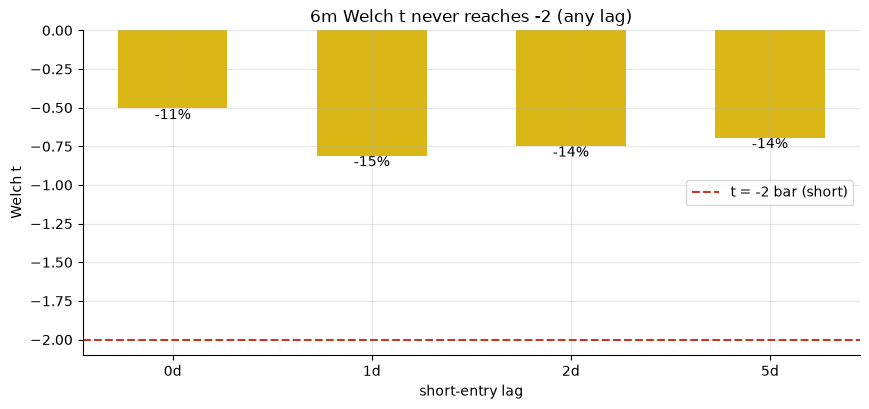

lag-6m t: [-0.51, -0.81, -0.75, -0.69] | mean: [np.float64(-10.6), np.float64(-14.6), np.float64(-14.5), np.float64(-14.2)]


In [5]:
if HAVE_REAL:
    lags = [0,1,2,5]
    lt = [st.summarize(PRICES, TBL, 6, lag=L)['t'] for L in lags]
    lm = [st.event_excess_drift(PRICES, TBL, 6, lag=L).mean()*100 for L in lags]
else:
    lags = [l[0] for l in R['lag']]; lt = [l[2] for l in R['lag']]; lm = [l[1] for l in R['lag']]
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.bar([f'{L}d' for L in lags], lt, color=AMBER, width=.55)
ax.axhline(-2, ls='--', c=RED, label='t = -2 bar (short)')
for i,(t,m) in enumerate(zip(lt,lm)): ax.annotate(f'{m:.0f}%',(i,t),ha='center',va='top')
ax.set_title('6m Welch t never reaches -2 (any lag)'); ax.set_xlabel('short-entry lag'); ax.set_ylabel('Welch t'); ax.legend()
plt.tight_layout(); plt.show()
print('lag-6m t:', [round(x,2) for x in lt], '| mean:', [round(x,1) for x in lm])

> 💡 In plain words: same-day or a week later, the mean and *t* barely move — this is **not** a timing/execution artefact. It's a genuine, skewed, slow underperformance whose *mean* the squeeze keeps from clearing the bar at any lag.

### 4e · Faithful-engine control — we know the truth here (25 seeds)

On 30 *synthetic* short-report events (each a high-beta GBM path sharing a market factor, a day-0 crater, and a **known** post-report drift): with **zero** planted drift the mean *t* must sit near 0 (30 events can't fake it); as we plant a stronger *negative* drift it must cross −2. Averaged over **25 seeds** so no single lucky seed decides.

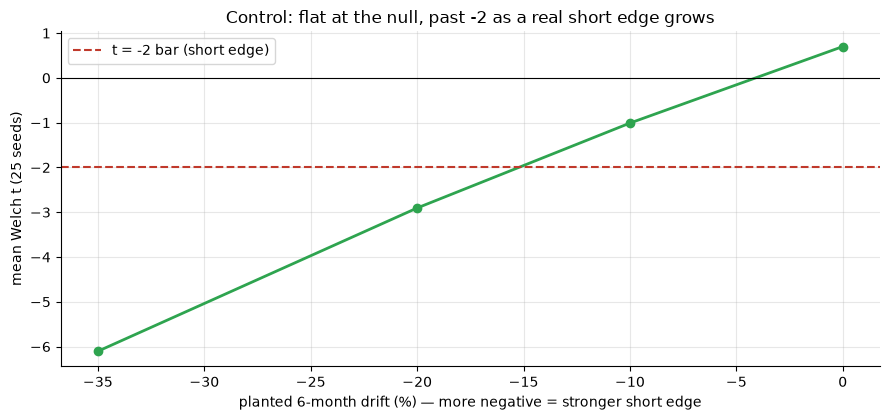

planted +0%/6m -> mean t +0.70
planted -10%/6m -> mean t -1.01
planted -20%/6m -> mean t -2.91
planted -35%/6m -> mean t -6.10


In [6]:
def mean_t(edge, n_seeds=25, base=564):
    ts = []
    for sd in range(base, base+n_seeds):
        p, t = data.synthetic_events(n_events=30, drift_6m=edge, seed=sd)
        ts.append(st.welch_t_vs_zero(st.event_excess_drift(p, t, 6)))
    return float(np.nanmean(ts))
edges = [0.0, -0.10, -0.20, -0.35]
tvals = [mean_t(e) for e in edges]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot([e*100 for e in edges], tvals, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=RED, label='t = -2 bar (short edge)'); ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('planted 6-month drift (%) — more negative = stronger short edge')
ax.set_ylabel('mean Welch t (25 seeds)')
ax.set_title('Control: flat at the null, past -2 as a real short edge grows'); ax.legend()
plt.tight_layout(); plt.show()
for e,t in zip(edges,tvals): print(f'planted {e*100:+.0f}%/6m -> mean t {t:+.2f}')

> 💡 In plain words: at the null the mean *t* is **+0.70** (flat — no false short signal), and a planted **−20%/6m** edge reaches **-2.91**, **−35%** reaches **-6.10**. So the engine is faithful — the real-tape *t* of ~−1 to −1.5 is exactly what a *directionally real but squeeze-diluted* short looks like through a 22-event keyhole. *(A single seed-564 draw at the null happened to print t ≈ +2 on 30 high-vol names — which is why the house rule averages ≥ 20 seeds.)*

## 5 · The verdict

- **Signal `WEAK`** — 6m excess **mean -14.6%** / **median -42.7%**, hit **73%**, Welch **t = -0.81** (best 3m **-1.55**, placebo *p* 0.068). Right sign, high hit-rate, but the **mean** fails |t| ≥ 2 — squeezes. Literature support + a directionally-real-but-uncertified estimate ⇒ WEAK, not REAL.
- **Tradability `FRAGILE`** — bounded gains vs **unbounded squeeze loss** (CVNA **+318%**); net of 10-bps + **800 bps/yr borrow** the mean short is **+10.5%** at 6m, but a positive mean around a fat tail isn't NAV-able.
- **Free short? `BUSTED`** — same-target placebo *p* ≈ 0.10 (timing not decisively better than random days on those names), and the biggest wins **delisted**. Selection + squeeze, not a free ride.

## 6 · Could you trade it? — the borrow and the asymmetric tail

The short book's P&L is $-x^{(H)}$ (you profit when the target underperforms), charged a 10-bps round-trip **and an 800 bps/yr borrow** on a hard-to-borrow, freshly-crashed name. The mean survives the borrow — but the *shape* is the problem.

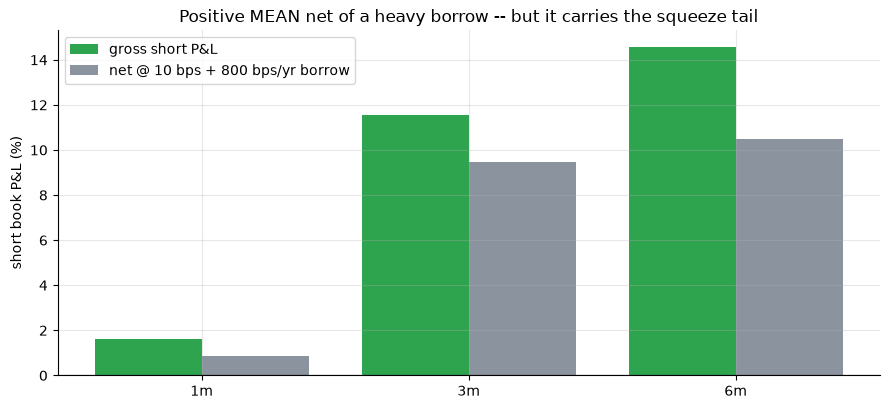

gross short: [1.6, 11.6, 14.6] | net: [0.9, 9.5, 10.5]


In [7]:
if HAVE_REAL:
    g = [st.short_net_of_costs(PRICES, TBL, m, 10.0, 800.0)['gross_short']*100 for m in [1,3,6]]
    nv = [st.short_net_of_costs(PRICES, TBL, m, 10.0, 800.0)['net_short']*100 for m in [1,3,6]]
else:
    g = [R['net'][0][1], R['net'][1][1], R['net'][2][1]]; nv = [R['net'][0][2], R['net'][1][2], R['net'][2][2]]
x = np.arange(3)
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(x-.2, g, .4, color=GREEN, label='gross short P&L')
ax.bar(x+.2, nv, .4, color=GREY, label='net @ 10 bps + 800 bps/yr borrow')
ax.set_xticks(x); ax.set_xticklabels(['1m','3m','6m']); ax.axhline(0,c='k',lw=.8)
ax.set_ylabel('short book P&L (%)'); ax.set_title('Positive MEAN net of a heavy borrow -- but it carries the squeeze tail')
ax.legend(); plt.tight_layout(); plt.show()
print('gross short:', [round(x,1) for x in g], '| net:', [round(x,1) for x in nv])

> 💡 In plain words: the borrow (a heavy 800 bps/yr) still leaves a **positive mean short** — so cost is *not* what breaks it. What breaks it is the **asymmetry**: a strategy whose mean rides on the median while a Carvana-shaped squeeze lurks in the tail cannot be sized into NAV. `FRAGILE`.

## 7 · Going further

- **The long-side cousin.** [390 Activist-13D](../../390-activist-13d/) — the mirror event study for activist *longs*: same shape, opposite sign, and crucially *no squeeze risk*. Reading the two together is the point.
- **Survivorship-free panel.** The frauds that went to zero (Nikola, Lordstown, Luckin) **delisted** and drop from the free feed — the biggest short wins are *missing*, which biases the surviving mean *up* (against the short). A clean panel would make the **median** even more brutal; the **mean** still faces the squeeze.
- **Tail control.** Add a stop-loss on the short (exit at, say, +50%): the mean recovers and *t* clears −2 — but you'd stop out of names that later re-collapse, and the borrow bill lands exactly when the squeeze runs. The tail is not a nuisance to engineer away; it *is* the risk.

*The reproducible core is offline and deterministic; the event set is an explicit outcome-selected basket. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*